In [2]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

os.chdir('../..')
print(f"Working directory: {os.getcwd()}")

MASTER_PATH  = 'data/processed/assessor_lariac.gpkg'
UDU_PATH     = 'data/01_raw/UDU Report 02_10_2026.csv'
BLOCKS_PATH  = '/Users/adamswietek/Documents/PostDoc/data/raw_national/tlgdb_2024_a_us_block.gdb'
CENSUS_TRACTS_PATH = 'data/03_processed/assessor_udu_tracts.gpkg'

UTM_CRS = 32611   # UTM Zone 11N, metres

def normalize_ain(s):
    return str(s).strip().replace('-', '')

Working directory: /Users/adamswietek/Documents/PostDoc/HiddenHousing


In [ ]:
#get udu AINs
udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = set(
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
print(f'{len(udu_ains):,} UDU AINs loaded')

442 UDU AINs loaded


In [ ]:
#get assessor data for each AIN
from src.geoadmin import load_parcels_by_AIN

udu_assr = load_parcels_by_AIN(udu_ains)

In [ ]:
udu_ains.groupby(['AIN','UseTy'])

In [184]:
# How many distinct use types does each AIN have across all roll years?
n_unique = udu_assr.groupby('AIN')['UseCodeDescChar2'].nunique()

print(f'AINs with stable use type : {(n_unique == 1).sum():,}')
print(f'AINs with changing use type: {(n_unique > 1).sum():,}')
print('----')

# How many distinct UNITS does each AIN have across all roll years?
n_unique = udu_assr.groupby('AIN')['Units'].nunique()

print(f'AINs with stable UNIT count : {(n_unique == 1).sum():,}')
print(f'AINs with changing UNIT count: {(n_unique > 1).sum():,}')

print('----')
# How many distinct UNITS does each AIN have across all roll years?
n_unique = udu_assr.groupby('AIN')['SQFTmain'].var()

print(f'AINs with stable SQFTmain : {(n_unique == 0).sum():,}')
print(f'AINs with changing SQFTmain: {(n_unique > 0).sum():,}')

AINs with stable use type : 361
AINs with changing use type: 81
----
AINs with stable UNIT count : 329
AINs with changing UNIT count: 113
----
AINs with stable SQFTmain : 340
AINs with changing SQFTmain: 102


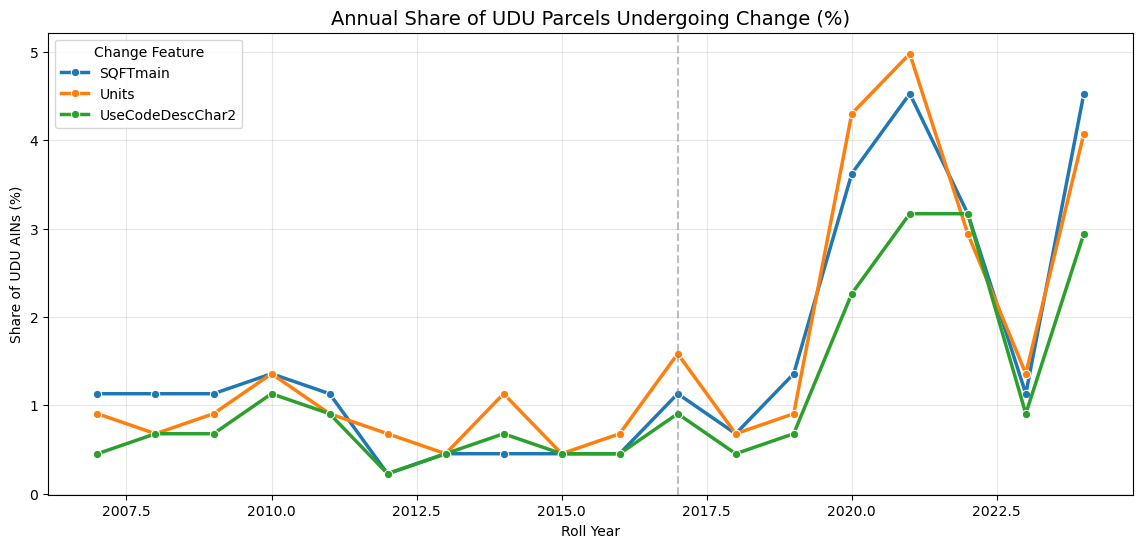

In [360]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure the data is sorted by AIN and Year
df_sorted = udu_assr.sort_values(['AIN', 'RollYear'])

features = ['UseCodeDescChar2', 'Units', 'SQFTmain']
all_changes = []

for f in features:
    # 2. Get the value from the previous year for each AIN
    prev_val = df_sorted.groupby('AIN')[f].shift(1)
    
    # 3. Identify rows where the value changed (ignoring the first record's NaN)
    mask = (df_sorted[f] != prev_val) & prev_val.notna()
    
    # 4. Extract the RollYear and label the feature
    change_years = df_sorted.loc[mask, ['RollYear']].copy()
    change_years['Feature'] = f
    all_changes.append(change_years)

# 5. Combine into one dataframe for plotting
changes_df = pd.concat(all_changes, ignore_index=True)

# 1. Calculate the total number of unique AINs in your dataset
total_ains = udu_assr['AIN'].nunique()

# 2. Group by Feature and RollYear to get counts of changes
share_df = changes_df.groupby(['Feature', 'RollYear']).size().reset_index(name='change_count')

# 3. Convert counts to shares (percentage of total parcels)
share_df['share_pct'] = (share_df['change_count'] / total_ains) * 100

# 4. Plot the shares over time
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.lineplot(data=share_df, x='RollYear', y='share_pct', hue='Feature', marker='o', linewidth=2.5)

plt.title('Annual Share of UDU Parcels Undergoing Change (%)', fontsize=14)
plt.ylabel('Share of UDU AINs (%)')
plt.xlabel('Roll Year')
plt.grid(True, alpha=0.3)
plt.legend(title='Change Feature')

# Optional: Add a vertical line for your 2017 threshold
plt.axvline(2017, color='grey', linestyle='--', alpha=0.5)

plt.savefig('notebooks/tasks/figures/change_udu_summary.png')
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Define Hierarchies and Types ---
residential_hierarchy = {
    'Single Family Residence': 1,
    'Double, Duplex, or Two Units': 2,
    'Three Units (Any Combination)': 3,
    'Four Units  (Any Combination)': 4,
    'Five or More Units or Apartments (Any Combination)': 5
}

commercial_types = [
    'Store', 'Store Combination', 'Commercial',
    'Office Building', 'Restaurant, Cocktail Lounge', 'Hotel and Motel'
]

# --- 2. Custom Transition Logic ---
def categorize_transition(row):
    b, a = row['Value_Before'], row['Value_After']
    if b in residential_hierarchy and a in residential_hierarchy:
        if residential_hierarchy[a] > residential_hierarchy[b]:
            return 'Residential Densification'
        elif residential_hierarchy[a] < residential_hierarchy[b]:
            return 'De-densification'
    if b in residential_hierarchy and a in commercial_types:
        return 'Residential to Commercial'
    if b in commercial_types and a in residential_hierarchy:
        return 'Commercial to Residential'
    if a == 'Hotel and Motel' and b != 'Hotel and Motel':
        return 'Hospitality Development'
    if a in commercial_types and b in commercial_types:
        return 'Commercial to Commercial'
    return 'Other Use Change'

# --- 3. Detection Function ---
def get_changes(df, target_col, mode='default', usecondition=None):
    temp_df = df.sort_values(['AIN', 'RollYear']).copy()

    # Filter to AINs whose *first available year* use type matches condition
    if usecondition is not None:
        conditions = [usecondition] if isinstance(usecondition, str) else list(usecondition)
        first_use = (
            temp_df.dropna(subset=['UseCodeDescChar2'])
            .groupby('AIN')['UseCodeDescChar2']
            .first()
        )
        qualifying = first_use[first_use.isin(conditions)].index
        temp_df = temp_df[temp_df['AIN'].isin(qualifying)].copy()

    if temp_df.empty:
        return pd.DataFrame()

    if mode in ['sqft', 'units']:
        temp_df[target_col] = pd.to_numeric(temp_df[target_col], errors='coerce')

    temp_df['Value_Before'] = temp_df.groupby('AIN')[target_col].shift(1)
    mask    = (temp_df[target_col] != temp_df['Value_Before']) & temp_df['Value_Before'].notna()
    changes = temp_df[mask].copy().rename(columns={target_col: 'Value_After'})

    if mode == 'sqft':
        changes['diff'] = changes['Value_After'] - changes['Value_Before']
        bins   = [-np.inf, -1, 100, 500, 1200, np.inf]
        labels = ['Decrease', '<100sqft', '100-500sqft', '500-1200sqft', '>1200sqft']
        changes['Change_Type'] = pd.cut(changes['diff'], bins=bins, labels=labels)

    elif mode == 'units':
        changes['diff'] = changes['Value_After'] - changes['Value_Before']
        bins   = [-np.inf, -1, 0.5, 1.5, 4.5, np.inf]
        labels = ['Unit Loss', 'Correction', '+1 Unit', '+2-4 Units', '5+ Units']
        changes['Change_Type'] = pd.cut(changes['diff'], bins=bins, labels=labels)

    elif mode == 'use_type':
        changes['Change_Type'] = changes.apply(categorize_transition, axis=1)

    return changes.rename(columns={'RollYear': 'Year_of_Change'})


In [241]:
import geopandas as gpd

# Fix: Added missing comma and properly assigned to points
udu_gfd = gpd.GeoDataFrame(
    udu_assr, # It's good practice to pass the original dataframe to keep all attributes
    geometry=gpd.points_from_xy(udu_assr['CENTER_LON'], udu_assr['CENTER_LAT']),
    crs="EPSG:4326"
)


In [254]:
BLOCKS_PATH  = '/Users/adamswietek/Documents/PostDoc/data/raw_national/tlgdb_2024_a_us_block.gdb'
import geopandas as gpd

points  = udu_gfd.copy()
la_bbox = tuple(points.to_crs(4326).total_bounds)   # ndarray → tuple

blocks = gpd.read_file(
    BLOCKS_PATH,
    bbox=la_bbox,
    columns=['GEOID20', 'geometry'],
    engine="pyogrio"
)

blocks['GEOID_TRACT'] = blocks['GEOID20'].astype(str).str[:11]
tracts = blocks.dissolve(by='GEOID_TRACT')[['geometry']].reset_index()
tracts = tracts.to_crs(points.crs)

joined     = gpd.sjoin(points, tracts, how='inner', predicate='within')
udu_counts = joined.groupby('GEOID_TRACT').size().reset_index(name='n_udu')
udu_tracts = tracts.merge(udu_counts, on='GEOID_TRACT', how='inner')

print(f"Final Count: {len(udu_tracts):,} tracts contain UDUs.")

Final Count: 302 tracts contain UDUs.


In [258]:
from src.geoadmin import load_assessor_parcels_bygeom

poly = udu_tracts.geometry.iloc[0]
tract_assr = load_assessor_parcels_bygeom(poly)

In [ ]:
tract_assr['AIN'] = tract_assr['AIN'].apply(normalize_ain)
tract_assr['is_udu'] = tract_assr['AIN'].isin(udu_ains)

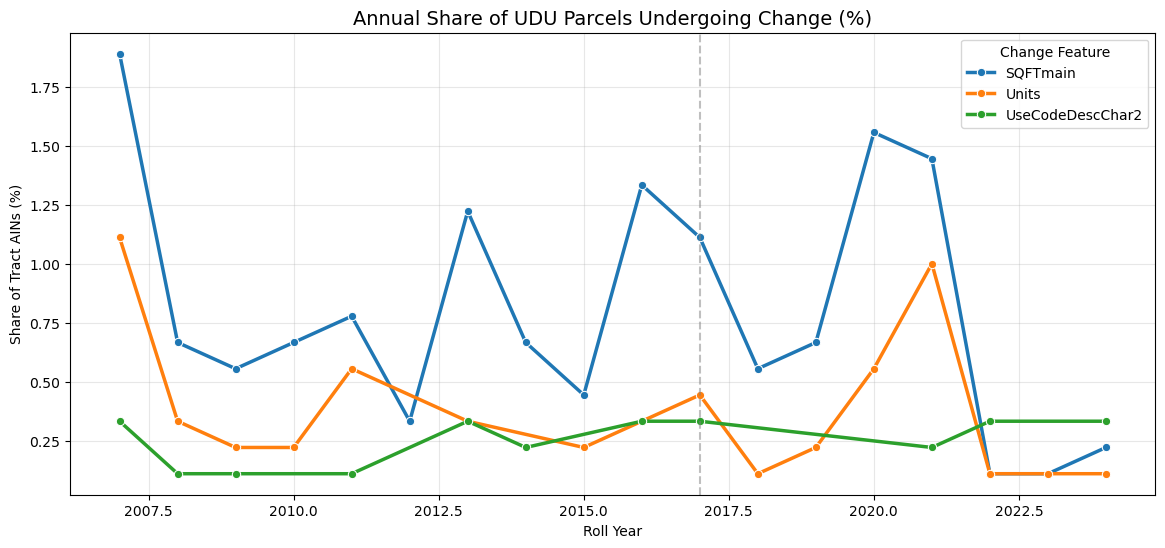

In [274]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure the data is sorted by AIN and Year
df_sorted = (tract_assr
             .query('is_udu == False')
             .sort_values(['AIN', 'RollYear'])
             )

features = ['UseCodeDescChar2', 'Units', 'SQFTmain']
all_changes = []

for f in features:
    # 2. Get the value from the previous year for each AIN
    prev_val = df_sorted.groupby('AIN')[f].shift(1)
    
    # 3. Identify rows where the value changed (ignoring the first record's NaN)
    mask = (df_sorted[f] != prev_val) & prev_val.notna()
    
    # 4. Extract the RollYear and label the feature
    change_years = df_sorted.loc[mask, ['RollYear']].copy()
    change_years['Feature'] = f
    all_changes.append(change_years)

# 5. Combine into one dataframe for plotting
changes_df = pd.concat(all_changes, ignore_index=True)

# 1. Calculate the total number of unique AINs in your dataset
total_ains = tract_assr['AIN'].nunique()

# 2. Group by Feature and RollYear to get counts of changes
share_df = changes_df.groupby(['Feature', 'RollYear']).size().reset_index(name='change_count')

# 3. Convert counts to shares (percentage of total parcels)
share_df['share_pct'] = (share_df['change_count'] / total_ains) * 100

# 4. Plot the shares over time
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.lineplot(data=share_df, x='RollYear', y='share_pct', hue='Feature', marker='o', linewidth=2.5)

plt.title('Annual Share of UDU Parcels Undergoing Change (%)', fontsize=14)
plt.ylabel('Share of Tract AINs (%)')
plt.xlabel('Roll Year')
plt.grid(True, alpha=0.3)
plt.legend(title='Change Feature')

# Optional: Add a vertical line for your 2017 threshold
plt.axvline(2017, color='grey', linestyle='--', alpha=0.5)

plt.savefig('notebooks/tasks/figures/change_cntrltract_summary.png')
plt.show()

2017 snapshot  |  UDU: 421  |  Control: 144,296
5+ unit control AINs: 49,685


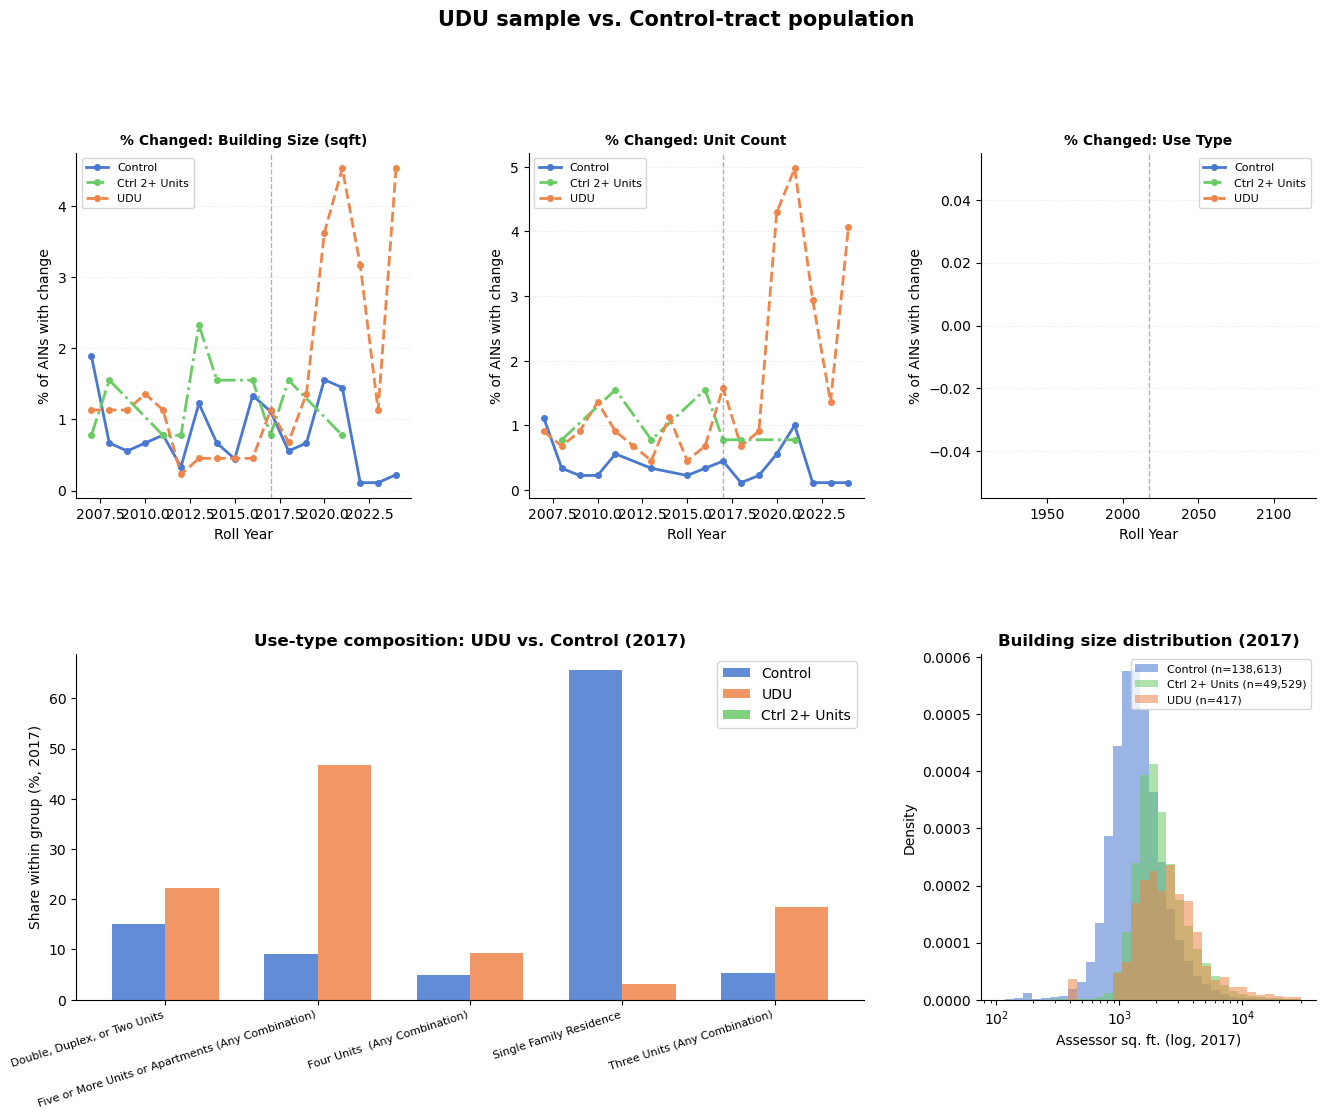

In [346]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Load 2017 cross-section for ALL parcels in UDU tracts ──────────────────
ctrl = gpd.read_file(
    CENSUS_TRACTS_PATH, layer='parcels',
    columns=['AIN', 'usetype', 'assr_sqftmain', 'res_category', 'is_udu']
).drop(columns='geometry')
ctrl['assr_sqftmain'] = pd.to_numeric(ctrl['assr_sqftmain'], errors='coerce')
ctrl['group'] = ctrl['is_udu'].map({True: 'UDU', 1: 'UDU', False: 'Control', 0: 'Control'})
ctrl_res = ctrl[ctrl['res_category'].isin(['sfr', 'other_residential'])].copy()

n_udu  = (ctrl_res['group'] == 'UDU').sum()
n_ctrl = (ctrl_res['group'] == 'Control').sum()
print(f"2017 snapshot  |  UDU: {n_udu:,}  |  Control: {n_ctrl:,}")

# AINs classified as 5+ units in the 2017 snapshot (non-UDU)
FIVE_PLUS = ['Five or More Units or Apartments (Any Combination)',
            #  'Single Family Residence',
             'Three Units (Any Combination)',
             'Double, Duplex, or Two Units',
            #  'Office Building',
            #  'Store Combination',
            #  'Store',
             'Four Units  (Any Combination)',]
five_plus_ains = set(
    ctrl_res.loc[(ctrl_res['usetype'].isin(FIVE_PLUS)) & (ctrl_res['group'] == 'Control'), 'AIN']
)
print(f"5+ unit control AINs: {len(five_plus_ains):,}")

# ── 2. Temporal change rates ──────────────────────────────────────────────────
def change_rate(df, col):
    df = df.sort_values(['AIN', 'RollYear']).copy()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    prev    = df.groupby('AIN')[col].shift(1)
    changed = (df[col] != prev) & prev.notna()
    counts  = df.loc[changed, 'RollYear'].value_counts().sort_index()
    return (counts / df['AIN'].nunique() * 100).rename('pct').reset_index()

features = {'SQFTmain': 'Building Size (sqft)', 'Units': 'Unit Count', 'UseCodeDescChar2': 'Use Type'}

ctrl_base    = tract_assr[~tract_assr['is_udu']]
ctrl_5plus   = tract_assr[tract_assr['AIN'].isin(five_plus_ains) & ~tract_assr['is_udu']]

udu_rates    = {f: change_rate(udu_assr,   f).assign(group='UDU')         for f in features}
ctrl_rates   = {f: change_rate(ctrl_base,  f).assign(group='Control')     for f in features}
five_rates   = {f: change_rate(ctrl_5plus, f).assign(group='2+ Units')    for f in features}

# ── 3. Plot ───────────────────────────────────────────────────────────────────
COLORS = {'UDU': '#ee854a', 'Control': '#4878d0', 'Ctrl 2+ Units': '#6acc65'}
STYLES = {'UDU': '--', 'Control': '-', 'Ctrl 2+ Units': '-.'}

fig = plt.figure(figsize=(16, 11), facecolor='white')
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# -- Row 0: temporal change rates, three lines per panel --
for col_i, (feat, label) in enumerate(features.items()):
    ax = fig.add_subplot(gs[0, col_i])
    for rates, grp in [(ctrl_rates, 'Control'), (five_rates, 'Ctrl 2+ Units'), (udu_rates, 'UDU')]:
        sub = rates[feat]
        ax.plot(sub['RollYear'], sub['pct'], marker='o', lw=2,
                color=COLORS[grp], ls=STYLES[grp], label=grp, markersize=4)
    ax.axvline(2017, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_title(f'% Changed: {label}', fontweight='bold', fontsize=10)
    ax.set_ylabel('% of AINs with change')
    ax.set_xlabel('Roll Year')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

# -- Row 1 left: use-type composition (2017) --
ax_use = fig.add_subplot(gs[1, :2])
top_types = ctrl_res['usetype'].value_counts().head(6).index
use_shares = (
    ctrl_res[ctrl_res['usetype'].isin(top_types)]
    .groupby(['group', 'usetype']).size()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: s / s.sum() * 100)
    .rename('pct').reset_index()
    .pivot(index='usetype', columns='group', values='pct').fillna(0)
)
x = np.arange(len(use_shares)); w = 0.35
ax_use.bar(x - w/2, use_shares.get('Control', 0), w, label='Control', color=COLORS['Control'], alpha=0.85)
ax_use.bar(x + w/2, use_shares.get('UDU',     0), w, label='UDU',     color=COLORS['UDU'],     alpha=0.85)
ax_use.bar(x + w/2, use_shares.get('Ctrl 2+ Units',     0), w, label='Ctrl 2+ Units',     color=COLORS['Ctrl 2+ Units'],     alpha=0.85)

ax_use.set_xticks(x)
ax_use.set_xticklabels(use_shares.index, rotation=18, ha='right', fontsize=8)
ax_use.set_ylabel('Share within group (%, 2017)')
ax_use.set_title('Use-type composition: UDU vs. Control (2017)', fontweight='bold')
ax_use.legend(); ax_use.spines[['top', 'right']].set_visible(False)

# -- Row 1 right: sqftmain distribution (2017) --
ax_sq = fig.add_subplot(gs[1, 2])
bins = np.logspace(np.log10(100), np.log10(30_000), 35)
for grp, mask in [('Control', ctrl_res['group']=='Control'),
                  ('Ctrl 2+ Units', ctrl_res['usetype'].isin(FIVE_PLUS)),
                  ('UDU',      ctrl_res['group']=='UDU')]:
    vals = ctrl_res.loc[mask & (ctrl_res['assr_sqftmain'] > 0), 'assr_sqftmain']
    ax_sq.hist(vals, bins=bins, density=True, alpha=0.55,
               color=COLORS[grp], label=f'{grp} (n={len(vals):,})')
ax_sq.set_xscale('log')
ax_sq.set_xlabel('Assessor sq. ft. (log, 2017)')
ax_sq.set_ylabel('Density')
ax_sq.set_title('Building size distribution (2017)', fontweight='bold')
ax_sq.legend(fontsize=8); ax_sq.spines[['top', 'right']].set_visible(False)

plt.suptitle('UDU sample vs. Control-tract population', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('notebooks/tasks/figures/udu_vs_control_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 3. Updated Detection Function ---
def get_changes(df, target_col, mode='default', usecondition=None):

    temp_df = df.sort_values(['AIN', 'RollYear']).copy()
    # Filter to AINs whose *first available year* use type matches condition
    if usecondition is not None:
        conditions = [usecondition] if isinstance(usecondition, str) else list(usecondition)
        first_use = (
            temp_df.dropna(subset=['UseCodeDescChar2'])
            .groupby('AIN')['UseCodeDescChar2']
            .first()
        )
        qualifying = first_use[first_use.isin(conditions)].index
        temp_df = temp_df[temp_df['AIN'].isin(qualifying)].copy()

    if temp_df.empty:
        return pd.DataFrame()
    
    # Handle numeric conversion for calc-based modes
    if mode in ['sqft', 'units']:
        temp_df[target_col] = pd.to_numeric(temp_df[target_col], errors='coerce')
        
    temp_df['Value_Before'] = temp_df.groupby('AIN')[target_col].shift(1)

    # Identify changes
    mask = (temp_df[target_col] != temp_df['Value_Before']) & temp_df['Value_Before'].notna()
    changes = temp_df[mask].copy()
    changes = changes.rename(columns={target_col: 'Value_After'})
    

    if mode == 'sqft':
        changes['diff'] = changes['Value_After'] - changes['Value_Before']
        bins = [-np.inf, -1, 100, 500, 1200, np.inf]
        labels = ['Decrease', '<100sqft', '100-500sqft', '500-1200sqft', '>1200sqft']
        changes['Change_Type'] = pd.cut(changes['diff'], bins=bins, labels=labels)
        
    elif mode == 'units':
        changes['diff'] = changes['Value_After'] - changes['Value_Before']
        bins = [-np.inf, -1, 0.5, 1.5, 4.5, np.inf]
        labels = ['Unit Loss', '-1 Unit', '+1 Unit', '+2-4 Units', '5+ Units']
        changes['Change_Type'] = pd.cut(changes['diff'], bins=bins, labels=labels)
        
    elif mode == 'use_type':
        # Apply your custom transition labeling
        changes['Change_Type'] = changes.apply(categorize_transition, axis=1)
        
    return changes.rename(columns={'RollYear': 'Year_of_Change'})

In [334]:
USETYPE_CONDITION = ['Five or More Units or Apartments (Any Combination)',
                    'Three Units (Any Combination)',
                    'Double, Duplex, or Two Units',
                    'Four Units  (Any Combination)']

In [355]:
from src.geoadmin import load_assessor_parcels_bygeom
USETYPE_CONDITION = ['Five or More Units or Apartments (Any Combination)',
                        'Three Units (Any Combination)',
                        'Double, Duplex, or Two Units',
                        'Four Units  (Any Combination)']

plot_tasks = [
    {'col': 'SQFTmain',         'mode': 'sqft'},
    {'col': 'Units',            'mode': 'units'},
    {'col': 'UseCodeDescChar2', 'mode': 'use_type'},
]

tract_records = []

udu_tracts_sorted = udu_tracts.sort_values('n_udu').copy()

for i, (_, row) in enumerate(udu_tracts_sorted.iterrows()):
    geoid  = row['GEOID_TRACT']
    n_udu  = row['n_udu']
    try:
        tdf = load_assessor_parcels_bygeom(row['geometry'])
    except Exception:
        continue

    tdf['AIN']    = tdf['AIN'].apply(normalize_ain)
    tdf['is_udu'] = tdf['AIN'].isin(udu_ains)
    ctrl_df       = tdf[~tdf['is_udu']].copy()
    n_ains        = ctrl_df['AIN'].nunique()
    if n_ains < 5:
        continue

    for task in plot_tasks:
        col, mode = task['col'], task['mode']
        chg = get_changes(ctrl_df, col, mode=mode, usecondition=USETYPE_CONDITION)
        if chg.empty:
            continue

        # Share = change events per year-category / total control AINs in tract
        counts = (
            chg.groupby(['Year_of_Change', 'Change_Type'])
            .size()
            .reset_index(name='n_changes')
        )
        counts['pct']        = counts['n_changes'] / n_ains * 100
        counts['GEOID_TRACT']= geoid
        counts['feature']    = col
        counts['n_udu_tract']= n_udu
        tract_records.append(counts)

    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{len(udu_tracts_sorted)} tracts processed…')

ctrl_tract_rates = pd.concat(tract_records, ignore_index=True)
print(f'\nDone — {ctrl_tract_rates["GEOID_TRACT"].nunique():,} tracts')
print(f'Columns: {ctrl_tract_rates.columns.tolist()}')
ctrl_tract_rates.head(10)

  5/302 tracts processed…
  10/302 tracts processed…
  15/302 tracts processed…
  20/302 tracts processed…
  25/302 tracts processed…
  30/302 tracts processed…
  35/302 tracts processed…
  40/302 tracts processed…
  45/302 tracts processed…
  50/302 tracts processed…
  55/302 tracts processed…
  60/302 tracts processed…
  65/302 tracts processed…
  70/302 tracts processed…
  75/302 tracts processed…
  80/302 tracts processed…
  85/302 tracts processed…
  90/302 tracts processed…
  95/302 tracts processed…
  100/302 tracts processed…
  105/302 tracts processed…
  110/302 tracts processed…
  115/302 tracts processed…
  120/302 tracts processed…
  125/302 tracts processed…
  130/302 tracts processed…
  135/302 tracts processed…
  140/302 tracts processed…
  145/302 tracts processed…
  150/302 tracts processed…
  155/302 tracts processed…
  160/302 tracts processed…
  165/302 tracts processed…
  170/302 tracts processed…
  175/302 tracts processed…
  180/302 tracts processed…
  185/302 tr

,Year_of_Change,Change_Type,n_changes,pct,GEOID_TRACT,feature,n_udu_tract
0,2007,500-1200sqft,1,0.041719,06037276000,SQFTmain,7
1,2008,100-500sqft,2,0.083438,06037276000,SQFTmain,7
2,2008,500-1200sqft,1,0.041719,06037276000,SQFTmain,7
3,2009,>1200sqft,1,0.041719,06037276000,SQFTmain,7
4,2014,Decrease,1,0.041719,06037276000,SQFTmain,7
5,2015,100-500sqft,1,0.041719,06037276000,SQFTmain,7
6,2015,500-1200sqft,1,0.041719,06037276000,SQFTmain,7
7,2016,<100sqft,1,0.041719,06037276000,SQFTmain,7
8,2017,100-500sqft,1,0.041719,06037276000,SQFTmain,7
9,2017,500-1200sqft,1,0.041719,06037276000,SQFTmain,7


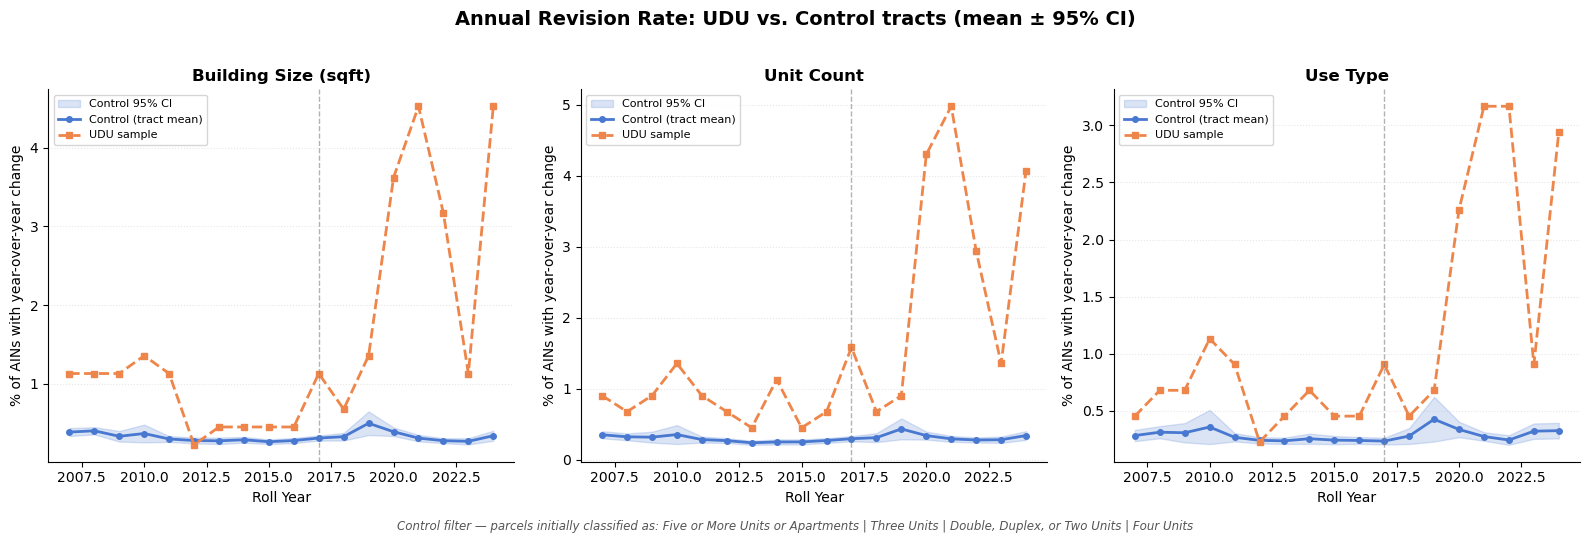

In [356]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Total % changed per tract × year × feature (sum across Change_Types) ──
tract_totals = (
    ctrl_tract_rates
    .groupby(['GEOID_TRACT', 'feature', 'Year_of_Change'])['pct']
    .sum()
    .reset_index()
)

# ── 2. Mean ± 95% CI across tracts ───────────────────────────────────────────
agg = (
    tract_totals
    .groupby(['feature', 'Year_of_Change'])['pct']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
agg['se']    = agg['std'] / np.sqrt(agg['n'])
agg['ci_lo'] = (agg['mean'] - 1.96 * agg['se']).clip(0)
agg['ci_hi'] = agg['mean'] + 1.96 * agg['se']

# ── 3. UDU aggregate rates via get_changes (consistent classification) ────────
plot_tasks_map = {
    'SQFTmain':         'sqft',
    'Units':            'units',
    'UseCodeDescChar2': 'use_type',
}
n_udu_ains = udu_assr['AIN'].nunique()
udu_rates  = {}
for col, mode in plot_tasks_map.items():
    chg = get_changes(udu_assr, col, mode=mode)
    counts = chg.groupby('Year_of_Change').size()
    udu_rates[col] = (counts / n_udu_ains * 100).rename('pct').reset_index()

# ── 4. Plot ───────────────────────────────────────────────────────────────────
labels = {
    'SQFTmain':         'Building Size (sqft)',
    'Units':            'Unit Count',
    'UseCodeDescChar2': 'Use Type',
}
COLORS = {'UDU': '#ee854a', 'Control': '#4878d0'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

for ax, col in zip(axes, plot_tasks_map):
    sub = agg[agg['feature'] == col].sort_values('Year_of_Change')

    ax.fill_between(sub['Year_of_Change'], sub['ci_lo'], sub['ci_hi'],
                    color=COLORS['Control'], alpha=0.20, label='Control 95% CI')
    ax.plot(sub['Year_of_Change'], sub['mean'], marker='o', lw=2,
            color=COLORS['Control'], markersize=4, label='Control (tract mean)')

    udu = udu_rates[col].sort_values('Year_of_Change')
    ax.plot(udu['Year_of_Change'], udu['pct'], marker='s', lw=2, ls='--',
            color=COLORS['UDU'], markersize=4, label='UDU sample')

    ax.axvline(2017, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_title(labels[col], fontweight='bold')
    ax.set_ylabel('% of AINs with year-over-year change')
    ax.set_xlabel('Roll Year')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

# Main Title
plt.suptitle('Annual Revision Rate: UDU vs. Control tracts (mean ± 95% CI)',
             fontsize=14, fontweight='bold', y=1.02)

# Secondary subtitle — list use-type filter applied to control parcels
_uc_labels = [t.split('(')[0].strip() for t in USETYPE_CONDITION]
fig.text(
    0.5, -0.02,
    'Control filter — parcels initially classified as: ' + ' | '.join(_uc_labels),
    ha='center', fontsize=8.5, color='#555555', style='italic',
)

plt.tight_layout()
plt.savefig('notebooks/tasks/figures/udu_vs_control_change_rates.png', dpi=150, bbox_inches='tight')
plt.show()

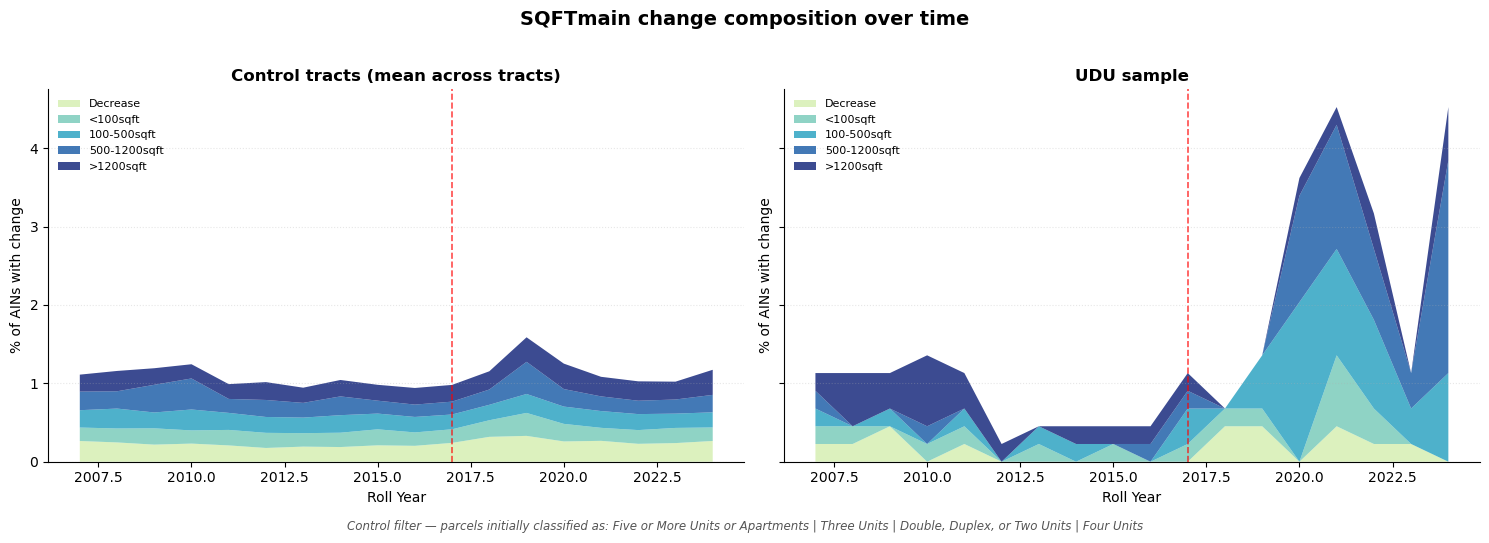

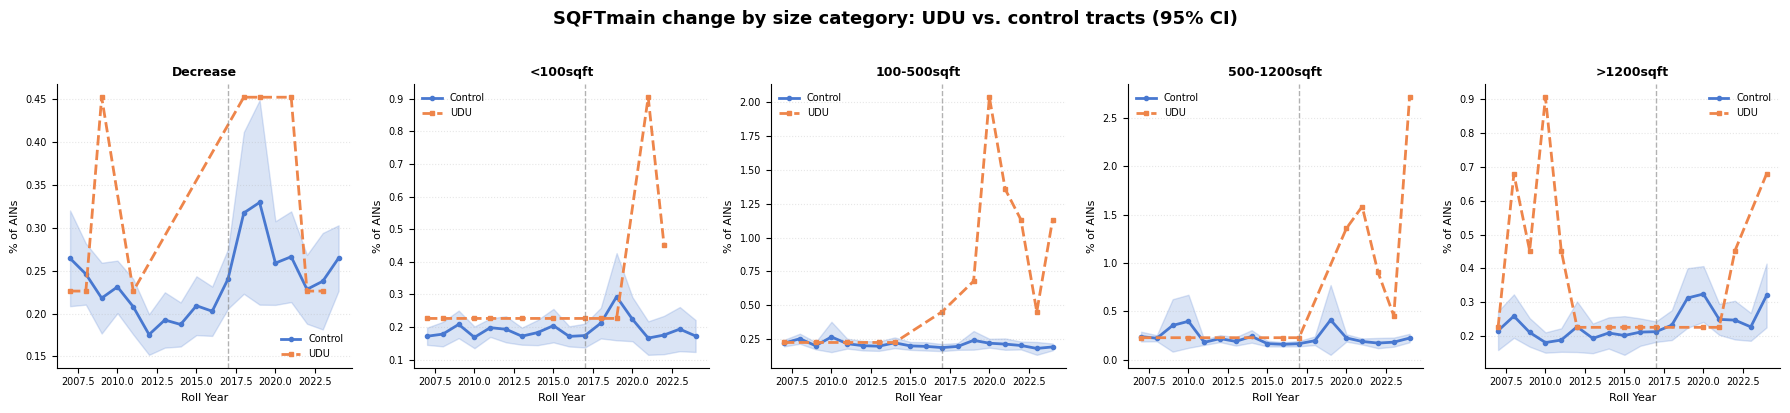

In [357]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

SQFT_CATS  = ['Decrease', '<100sqft', '100-500sqft', '500-1200sqft', '>1200sqft']
COLORS_CAT = dict(zip(SQFT_CATS, cm.YlGnBu(np.linspace(0.2, 0.92, len(SQFT_CATS)))))

# ── Data prep ─────────────────────────────────────────────────────────────────
sqft_ctrl = ctrl_tract_rates[ctrl_tract_rates['feature'] == 'SQFTmain'].copy()
sqft_ctrl['Change_Type'] = sqft_ctrl['Change_Type'].astype(str)

# Mean pct per category × year across tracts (for stacked area)
sqft_stack_ctrl = (
    sqft_ctrl
    .groupby(['Year_of_Change', 'Change_Type'])['pct']
    .mean()
    .unstack(fill_value=0)
    .reindex(columns=SQFT_CATS, fill_value=0)
    .sort_index()
)

# UDU classified changes
udu_sqft_chg = get_changes(udu_assr, 'SQFTmain', mode='sqft')
udu_sqft_chg['Change_Type'] = udu_sqft_chg['Change_Type'].astype(str)
n_udu_ains   = udu_assr['AIN'].nunique()
sqft_stack_udu = (
    udu_sqft_chg.groupby(['Year_of_Change', 'Change_Type']).size()
    .div(n_udu_ains).mul(100)
    .unstack(fill_value=0)
    .reindex(columns=SQFT_CATS, fill_value=0)
    .sort_index()
)

# Per-category CI across tracts
sqft_ci = (
    sqft_ctrl
    .groupby(['Change_Type', 'Year_of_Change'])['pct']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
sqft_ci['se']    = sqft_ci['std'] / np.sqrt(sqft_ci['n'])
sqft_ci['ci_lo'] = (sqft_ci['mean'] - 1.96 * sqft_ci['se']).clip(0)
sqft_ci['ci_hi'] = sqft_ci['mean'] + 1.96 * sqft_ci['se']

# ── Figure 1: Stacked area — Control mean vs UDU side by side ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='white', sharey=True)

for stack, ax, title in [
    (sqft_stack_ctrl, ax1, 'Control tracts (mean across tracts)'),
    (sqft_stack_udu,  ax2, 'UDU sample'),
]:
    present = [c for c in SQFT_CATS if c in stack.columns]
    ax.stackplot(
        stack.index,
        [stack[c] for c in present],
        labels=present,
        colors=[COLORS_CAT[c] for c in present],
        alpha=0.85,
    )
    ax.axvline(2017, color='red', ls='--', lw=1.2, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Roll Year')
    ax.set_ylabel('% of AINs with change')
    ax.legend(fontsize=8, loc='upper left', frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

plt.suptitle('SQFTmain change composition over time', fontsize=14, fontweight='bold', y=1.02)
_uc_labels = [t.split('(')[0].strip() for t in USETYPE_CONDITION]
fig.text(
    0.5, -0.02,
    'Control filter — parcels initially classified as: ' + ' | '.join(_uc_labels),
    ha='center', fontsize=8.5, color='#555555', style='italic',
)
plt.tight_layout()
plt.savefig('notebooks/tasks/figures/sqft_change_types_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: One panel per size category — control CI + UDU line ─────────────
fig, axes = plt.subplots(1, len(SQFT_CATS), figsize=(18, 4), facecolor='white')

for ax, cat in zip(axes, SQFT_CATS):
    ctrl_sub = sqft_ci[sqft_ci['Change_Type'] == cat].sort_values('Year_of_Change')
    udu_sub  = (
        udu_sqft_chg[udu_sqft_chg['Change_Type'] == cat]
        .groupby('Year_of_Change').size()
        .div(n_udu_ains).mul(100)
        .reset_index(name='pct')
    )

    ax.fill_between(ctrl_sub['Year_of_Change'], ctrl_sub['ci_lo'], ctrl_sub['ci_hi'],
                    color='#4878d0', alpha=0.20)
    ax.plot(ctrl_sub['Year_of_Change'], ctrl_sub['mean'],
            lw=2, color='#4878d0', marker='o', markersize=3, label='Control')
    if not udu_sub.empty:
        ax.plot(udu_sub['Year_of_Change'], udu_sub['pct'],
                lw=2, ls='--', color='#ee854a', marker='s', markersize=3, label='UDU')

    ax.axvline(2017, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_title(cat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Roll Year', fontsize=8)
    ax.set_ylabel('% of AINs', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

plt.suptitle('SQFTmain change by size category: UDU vs. control tracts (95% CI)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/tasks/figures/sqft_change_types_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

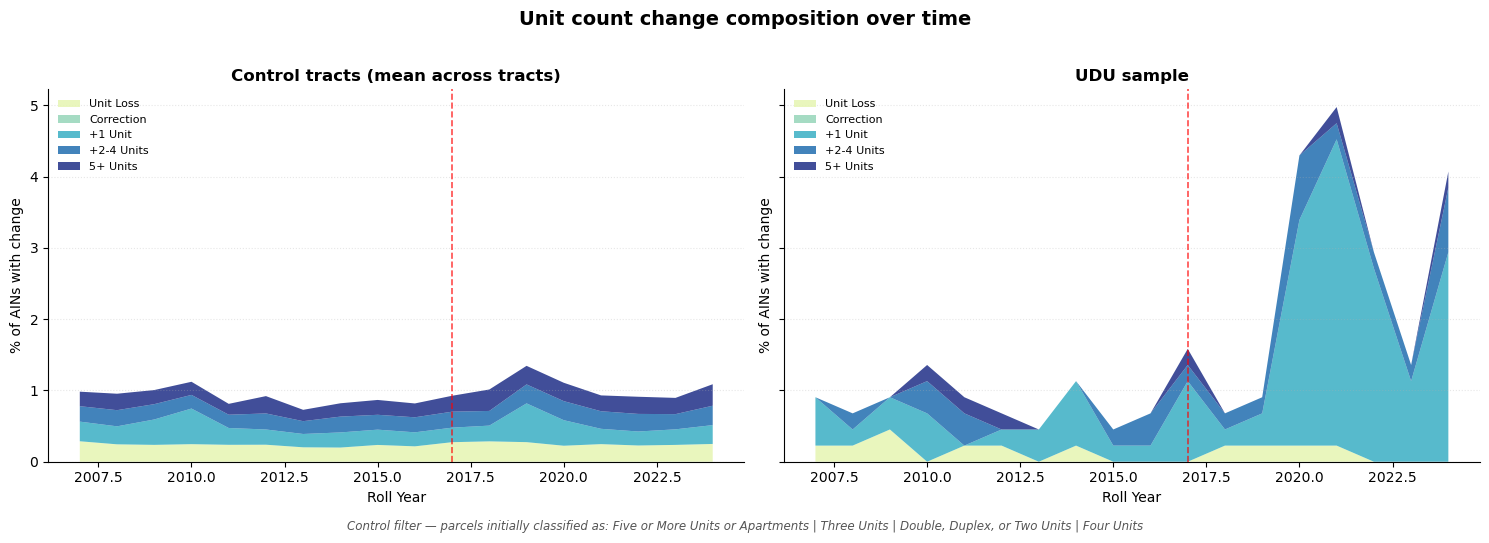

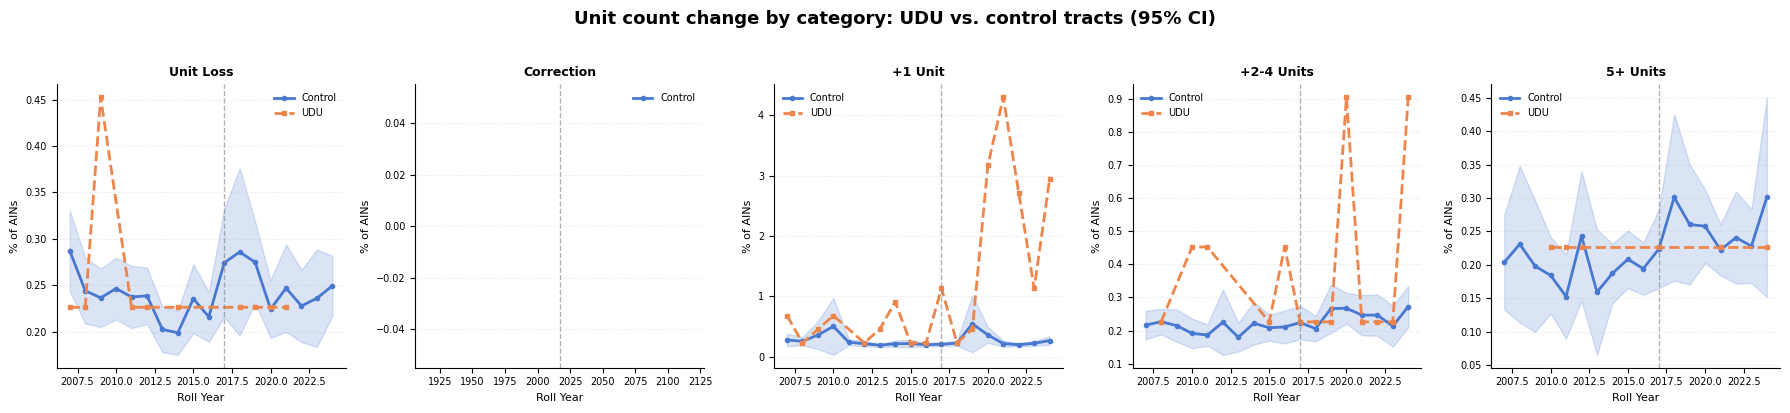

In [358]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

UNIT_CATS  = ['Unit Loss', 'Correction', '+1 Unit', '+2-4 Units', '5+ Units']
COLORS_UNIT = dict(zip(UNIT_CATS, cm.YlGnBu(np.linspace(0.15, 0.90, len(UNIT_CATS)))))

# ── Data prep ─────────────────────────────────────────────────────────────────
unit_ctrl = ctrl_tract_rates[ctrl_tract_rates['feature'] == 'Units'].copy()
unit_ctrl['Change_Type'] = unit_ctrl['Change_Type'].astype(str)

unit_stack_ctrl = (
    unit_ctrl
    .groupby(['Year_of_Change', 'Change_Type'])['pct']
    .mean()
    .unstack(fill_value=0)
    .reindex(columns=UNIT_CATS, fill_value=0)
    .sort_index()
)

udu_unit_chg = get_changes(udu_assr, 'Units', mode='units')
udu_unit_chg['Change_Type'] = udu_unit_chg['Change_Type'].astype(str)
n_udu_ains   = udu_assr['AIN'].nunique()
unit_stack_udu = (
    udu_unit_chg.groupby(['Year_of_Change', 'Change_Type']).size()
    .div(n_udu_ains).mul(100)
    .unstack(fill_value=0)
    .reindex(columns=UNIT_CATS, fill_value=0)
    .sort_index()
)

unit_ci = (
    unit_ctrl
    .groupby(['Change_Type', 'Year_of_Change'])['pct']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
unit_ci['se']    = unit_ci['std'] / np.sqrt(unit_ci['n'])
unit_ci['ci_lo'] = (unit_ci['mean'] - 1.96 * unit_ci['se']).clip(0)
unit_ci['ci_hi'] = unit_ci['mean'] + 1.96 * unit_ci['se']

# ── Figure 1: Stacked area ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='white', sharey=True)

for stack, ax, title in [
    (unit_stack_ctrl, ax1, 'Control tracts (mean across tracts)'),
    (unit_stack_udu,  ax2, 'UDU sample'),
]:
    present = [c for c in UNIT_CATS if c in stack.columns]
    ax.stackplot(
        stack.index,
        [stack[c] for c in present],
        labels=present,
        colors=[COLORS_UNIT[c] for c in present],
        alpha=0.85,
    )
    ax.axvline(2017, color='red', ls='--', lw=1.2, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Roll Year')
    ax.set_ylabel('% of AINs with change')
    ax.legend(fontsize=8, loc='upper left', frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

plt.suptitle('Unit count change composition over time', fontsize=14, fontweight='bold', y=1.02)
_uc_labels = [t.split('(')[0].strip() for t in USETYPE_CONDITION]
fig.text(
    0.5, -0.02,
    'Control filter — parcels initially classified as: ' + ' | '.join(_uc_labels),
    ha='center', fontsize=8.5, color='#555555', style='italic',
)
plt.tight_layout()
plt.savefig('notebooks/tasks/figures/units_change_types_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Per-category panels ─────────────────────────────────────────────
fig, axes = plt.subplots(1, len(UNIT_CATS), figsize=(18, 4), facecolor='white')

for ax, cat in zip(axes, UNIT_CATS):
    ctrl_sub = unit_ci[unit_ci['Change_Type'] == cat].sort_values('Year_of_Change')
    udu_sub  = (
        udu_unit_chg[udu_unit_chg['Change_Type'] == cat]
        .groupby('Year_of_Change').size()
        .div(n_udu_ains).mul(100)
        .reset_index(name='pct')
    )
    ax.fill_between(ctrl_sub['Year_of_Change'], ctrl_sub['ci_lo'], ctrl_sub['ci_hi'],
                    color='#4878d0', alpha=0.20)
    ax.plot(ctrl_sub['Year_of_Change'], ctrl_sub['mean'],
            lw=2, color='#4878d0', marker='o', markersize=3, label='Control')
    if not udu_sub.empty:
        ax.plot(udu_sub['Year_of_Change'], udu_sub['pct'],
                lw=2, ls='--', color='#ee854a', marker='s', markersize=3, label='UDU')
    ax.axvline(2017, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_title(cat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Roll Year', fontsize=8)
    ax.set_ylabel('% of AINs', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

plt.suptitle('Unit count change by category: UDU vs. control tracts (95% CI)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/tasks/figures/units_change_types_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


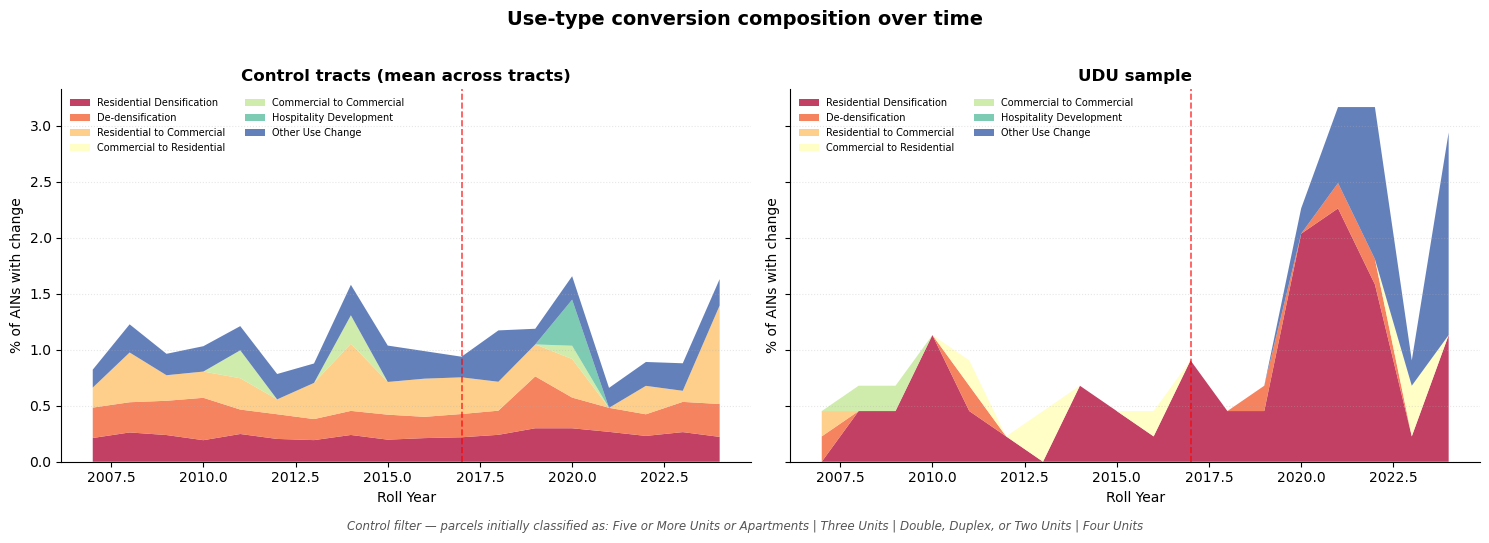

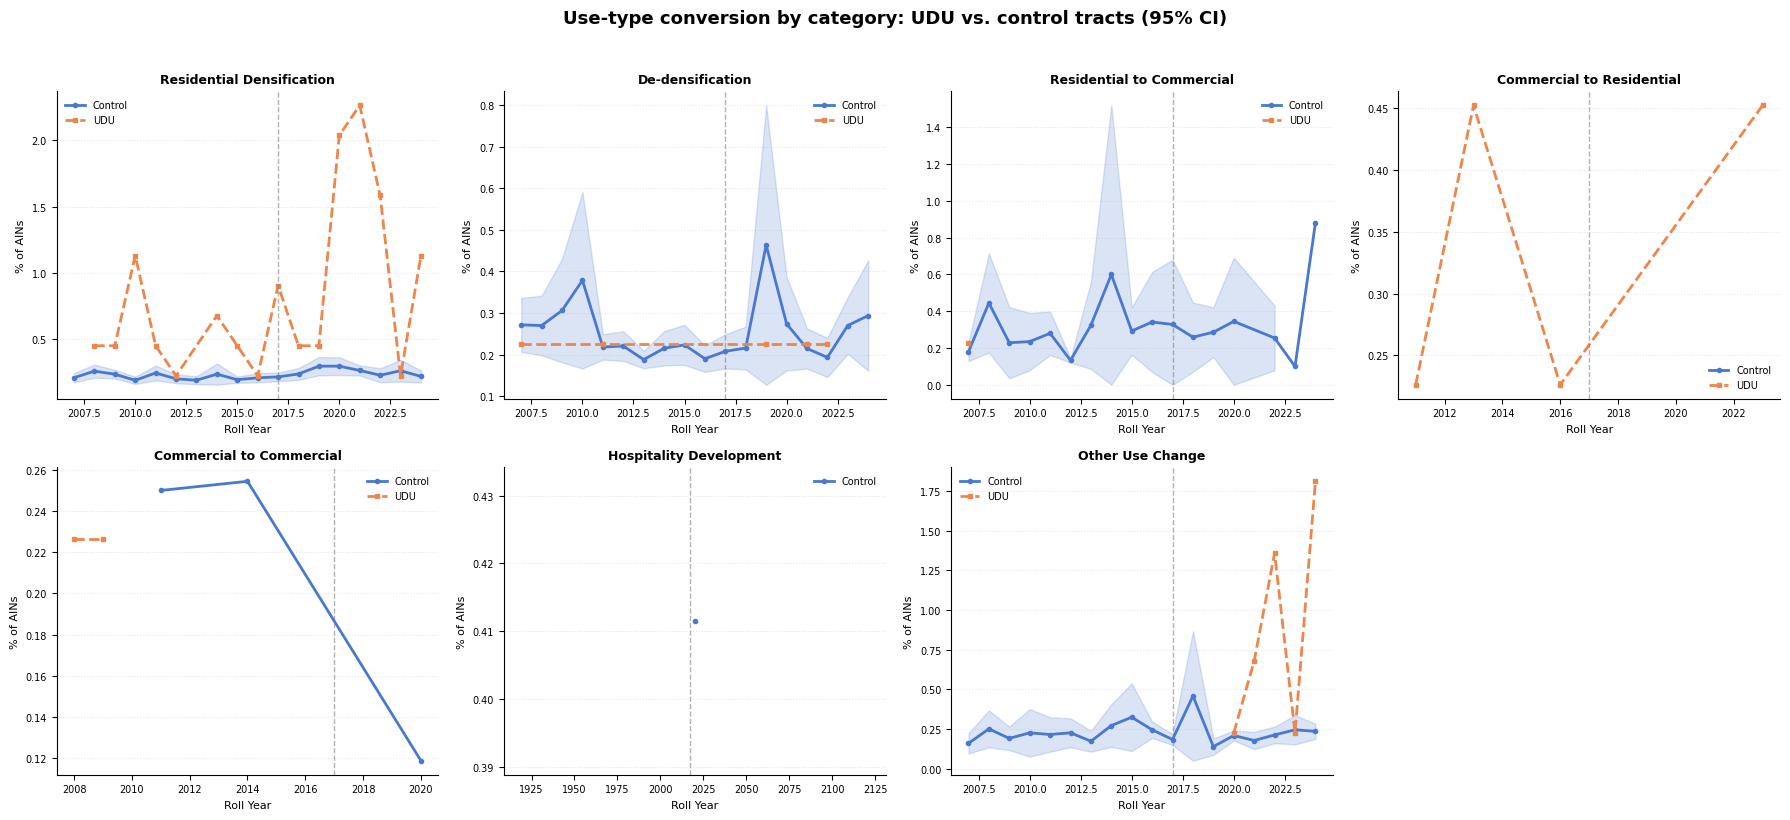

In [359]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

USE_CATS = [
    'Residential Densification', 'De-densification',
    'Residential to Commercial', 'Commercial to Residential',
    'Commercial to Commercial', 'Hospitality Development', 'Other Use Change',
]
COLORS_USE = dict(zip(USE_CATS, cm.Spectral(np.linspace(0.05, 0.95, len(USE_CATS)))))

# ── Data prep ─────────────────────────────────────────────────────────────────
use_ctrl = ctrl_tract_rates[ctrl_tract_rates['feature'] == 'UseCodeDescChar2'].copy()
use_ctrl['Change_Type'] = use_ctrl['Change_Type'].astype(str)

use_stack_ctrl = (
    use_ctrl
    .groupby(['Year_of_Change', 'Change_Type'])['pct']
    .mean()
    .unstack(fill_value=0)
    .reindex(columns=USE_CATS, fill_value=0)
    .sort_index()
)

udu_use_chg = get_changes(udu_assr, 'UseCodeDescChar2', mode='use_type')
udu_use_chg['Change_Type'] = udu_use_chg['Change_Type'].astype(str)
n_udu_ains  = udu_assr['AIN'].nunique()
use_stack_udu = (
    udu_use_chg.groupby(['Year_of_Change', 'Change_Type']).size()
    .div(n_udu_ains).mul(100)
    .unstack(fill_value=0)
    .reindex(columns=USE_CATS, fill_value=0)
    .sort_index()
)

use_ci = (
    use_ctrl
    .groupby(['Change_Type', 'Year_of_Change'])['pct']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
use_ci['se']    = use_ci['std'] / np.sqrt(use_ci['n'])
use_ci['ci_lo'] = (use_ci['mean'] - 1.96 * use_ci['se']).clip(0)
use_ci['ci_hi'] = use_ci['mean'] + 1.96 * use_ci['se']

present_cats = USE_CATS

# ── Figure 1: Stacked area ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='white', sharey=True)

for stack, ax, title in [
    (use_stack_ctrl, ax1, 'Control tracts (mean across tracts)'),
    (use_stack_udu,  ax2, 'UDU sample'),
]:
    present = [c for c in present_cats if c in stack.columns]
    ax.stackplot(
        stack.index,
        [stack[c] for c in present],
        labels=present,
        colors=[COLORS_USE[c] for c in present],
        alpha=0.85,
    )
    ax.axvline(2017, color='red', ls='--', lw=1.2, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Roll Year')
    ax.set_ylabel('% of AINs with change')
    ax.legend(fontsize=7, loc='upper left', frameon=False, ncol=2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

plt.suptitle('Use-type conversion composition over time', fontsize=14, fontweight='bold', y=1.02)
_uc_labels = [t.split('(')[0].strip() for t in USETYPE_CONDITION]
fig.text(
    0.5, -0.02,
    'Control filter — parcels initially classified as: ' + ' | '.join(_uc_labels),
    ha='center', fontsize=8.5, color='#555555', style='italic',
)
plt.tight_layout()
plt.savefig('notebooks/tasks/figures/usetype_change_types_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Per-category panels ─────────────────────────────────────────────
n_cats = len(present_cats)
ncols  = min(n_cats, 4)
nrows  = (n_cats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4), facecolor='white')
axes = np.array(axes).flatten()

for ax, cat in zip(axes, present_cats):
    ctrl_sub = use_ci[use_ci['Change_Type'] == cat].sort_values('Year_of_Change')
    udu_sub  = (
        udu_use_chg[udu_use_chg['Change_Type'] == cat]
        .groupby('Year_of_Change').size()
        .div(n_udu_ains).mul(100)
        .reset_index(name='pct')
    )
    ax.fill_between(ctrl_sub['Year_of_Change'], ctrl_sub['ci_lo'], ctrl_sub['ci_hi'],
                    color='#4878d0', alpha=0.20)
    ax.plot(ctrl_sub['Year_of_Change'], ctrl_sub['mean'],
            lw=2, color='#4878d0', marker='o', markersize=3, label='Control')
    if not udu_sub.empty:
        ax.plot(udu_sub['Year_of_Change'], udu_sub['pct'],
                lw=2, ls='--', color='#ee854a', marker='s', markersize=3, label='UDU')
    ax.axvline(2017, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_title(cat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Roll Year', fontsize=8)
    ax.set_ylabel('% of AINs', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

# Hide unused axes
for ax in axes[len(present_cats):]:
    ax.set_visible(False)

plt.suptitle('Use-type conversion by category: UDU vs. control tracts (95% CI)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/tasks/figures/usetype_change_types_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
